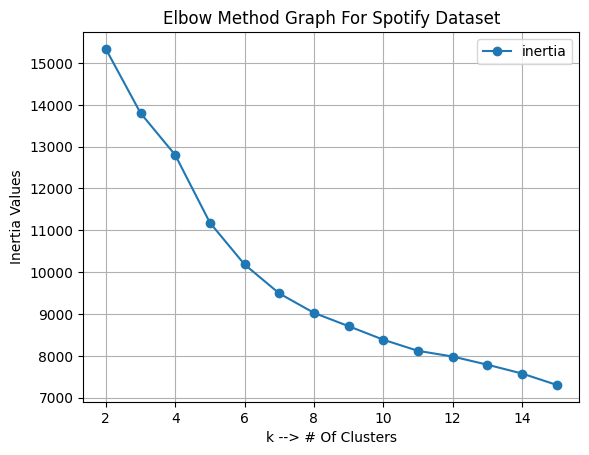

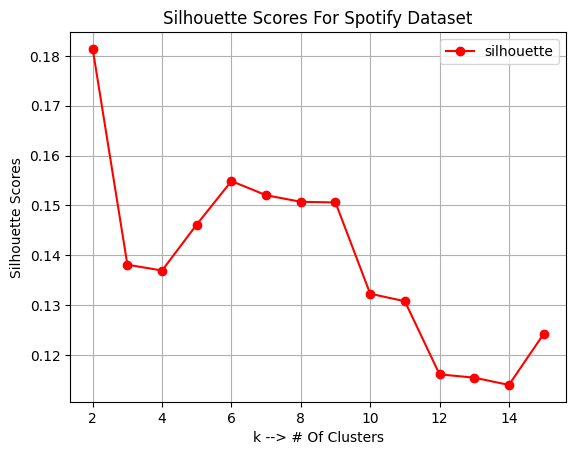

In [2]:
# IMPORTING NECESSARY LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ACCESSING SPOTIFY DATASET AND CONVERTING IT INTO A DATAFRAME
df = pd.read_csv("songs.csv")

# EXTRACTING SPOTIFY AUDIO FEATURES FROM ORIGINAL DATAFRAME AND PUTTING IT INTO A NEW DATAFRAME
music_attr = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]
cluster_df = df[music_attr]

# SCALING DATA SO THAT AUDIO FEATURES ALL HAVE EQUAL WEIGHT AND SCALES
scaled = StandardScaler().fit_transform(cluster_df)
scaled_df = pd.DataFrame(scaled, columns=music_attr)

# LOOPING THROUGH 15 k VALUES AND CALCULATING INERTIA SCORES FOR EACH k VALUE FOR ELBOW METHOD GRAPH
inertia_values = []
silhouette_scores = []

for test_k in range(2, 16):
    tmp_model = KMeans (
    n_clusters = test_k,
    n_init = 'auto',
    max_iter = 300,
    tol = 1e-4,
    random_state = 42
    )

    tmp_model.fit(scaled)
    values = tmp_model.inertia_
    inertia_values.append((test_k, values))

    scores = silhouette_score(scaled, tmp_model.labels_)
    silhouette_scores.append((test_k, scores))
        
# STORES INERTIA VALUES AND SILHOUETTE SCORES FROM LOOP INTO A DATAFRAME 
inertia_df = pd.DataFrame(inertia_values, columns = ["k", "inertia"])
silhouette_df = pd.DataFrame(silhouette_scores, columns = ["k", "silhouette"])

# PLOTS THE INERTIA SCORES STARTING FROM k=2 TO k=16, FORMING THE ELBOW METHOD VISUALIZATION TO HELP FIND IDEAL # OF CLUSTERS
inertia_df.plot("k", "inertia", marker="o")

plt.xlabel("k --> # Of Clusters")
plt.ylabel("Inertia Values")
plt.title("Elbow Method Graph For Spotify Dataset")
plt.grid(True)
plt.show()

# PLOTS THE SILHOUETTE SCORES STARTING FROM k=2 TO k=16, FORMING THE SILHOUETTE SCORE VISUALIZATION TO HELP FIND IDEAL # OF CLUSTERS
silhouette_df.plot("k", "silhouette", marker="o", color="red")

plt.xlabel("k --> # Of Clusters")
plt.ylabel("Silhouette Scores")
plt.title("Silhouette Scores For Spotify Dataset")
plt.grid(True)
plt.show()

In [3]:
# CHOOSING IDEAL NUMBER OF CLUSTER GROUPS TO FORM (k=6)
k = 6

# CREATES THE CLUSTER MODEL AND SEPARATES SONGS FROM THE DATASET INTO CLUSTER GROUPS
model = KMeans(n_clusters = k, n_init=20, random_state=42)
df['cluster'] = model.fit_predict(scaled)
scaled_df['cluster'] = df['cluster']

# CALCULATES THE MEAN (AVERAGE) OF EACH SPOTIFY FEATURE FOR EACH CLUSTER GROUP
scaled_cluster_means = scaled_df.groupby('cluster').mean()

# LOCATES THE HIGHEST AND LOWEST AVERAGE SPOTIFY AUDIO FEATURE MEASURE FOR EACH CLUSTER GROUP
for cluster_id, songs in df.groupby("cluster"):
    means = scaled_cluster_means.loc[cluster_id]    
    high_attr = means.idxmax()
    low_attr = means.idxmin()

    # PRINTS OUT THE CLUSTER GROUP, ITS SIZE, AND WHAT COMMON MUSIC CHARACTERISTICS IT CONTAINS
    print(f"Cluster: {cluster_id + 1} | Size: {songs.shape[0]}")
    print(f"HIGH {high_attr.upper()} | LOW {low_attr.upper()}")
    print("\t")
    print(f"Songs In Cluster {cluster_id + 1}: ")
    print("\n")

    # PRINTS OUT 5 RANDOM SONGS WITHIN EACH CLUSTER
    sample_size = min(5, len(songs))
    for idx in songs.sample(sample_size).index:
        song = df.loc[idx, "song"]
        artist = df.loc[idx, "artist"]
        print(f"\t{song}: {artist}")
    print("\n")

Cluster: 1 | Size: 528
HIGH TEMPO | LOW VALENCE
	
Songs In Cluster 1: 


	Demons: Imagine Dragons
	Dancing On My Own: Robyn
	Drinking from the Bottle (feat. Tinie Tempah): Calvin Harris
	Oh (feat. Ludacris): Ciara
	Silence: Marshmello


Cluster: 2 | Size: 242
HIGH LIVENESS | LOW ACOUSTICNESS
	
Songs In Cluster 2: 


	Hands Clean: Alanis Morissette
	Donald Trump: Mac Miller
	Starlight - Radio Edit: The Supermen Lovers
	Lady Marmalade - From "Moulin Rouge" Soundtrack: Christina Aguilera
	Do It To It: Cherish


Cluster: 3 | Size: 663
HIGH VALENCE | LOW LIVENESS
	
Songs In Cluster 3: 


	Échame La Culpa: Luis Fonsi
	Bad Romance: Lady Gaga
	In Your Eyes: Kylie Minogue
	Don't Call Me Baby: Madison Avenue
	Body (feat. brando): Loud Luxury


Cluster: 4 | Size: 270
HIGH SPEECHINESS | LOW ENERGY
	
Songs In Cluster 4: 


	Home (with Machine Gun Kelly, X Ambassadors & Bebe Rexha): Machine Gun Kelly
	Rainy Dayz: Mary J. Blige
	Air Force Ones: Nelly
	Rake It Up (feat. Nicki Minaj): Yo Gotti
	Where t